location=austin | grid_source=smart_ds | assets=2014638 | flood=none


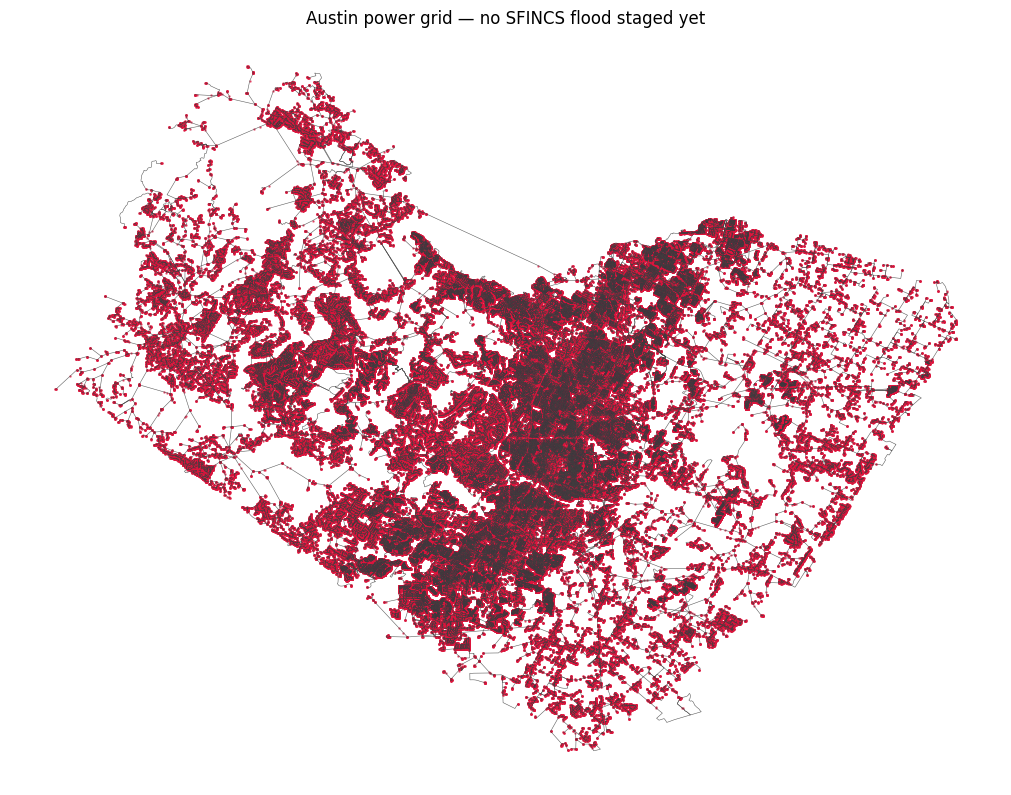

In [1]:
# Power grid x SFINCS flood overlay -- portable across Flood-RM locations.
# Resolves CRS from the SFINCS map, auto-detects the grid source (SMART-DS geojson or
# asset-registry CSVs), and finds the flood layer wherever the location stages it.
from pathlib import Path
import geopandas as gpd
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from shapely.geometry import LineString

location_root = Path("..").resolve()
location_name = location_root.name

# --- locate the flood layer (inland scenarios/<event>/<domain>/ or coastal run_outputs/<event>/) ---
flood_maps = sorted((location_root / "data" / "sfincs").glob("**/sfincs_map.nc"))
flood_map = flood_maps[-1] if flood_maps else None

# --- load the power grid from whichever source this location provides ---
def load_grid():
    geojsons = sorted((location_root / "data" / "smart_ds").glob("*/*/scenarios/base_timeseries/geojson/*.json"))
    if geojsons:  # SMART-DS feeders (greensboro, austin, sfo)
        g = pd.concat([gpd.read_file(p) for p in geojsons], ignore_index=True)
        if "type" not in g:
            g["type"] = "Node"
        return g[["type", "geometry"]].to_crs("EPSG:4326"), "smart_ds"
    reg = location_root / "data" / "power_grid" / "asset_registry"
    if reg.exists():  # OpenDSS asset registry (marshfield)
        def pts(csv, lon, lat, type_):
            df = pd.read_csv(reg / csv).dropna(subset=[lon, lat])
            gdf = gpd.GeoDataFrame(geometry=gpd.points_from_xy(df[lon], df[lat]), crs="EPSG:4326")
            gdf["type"] = type_
            return gdf
        frames = [
            pts("transformers.csv", "location_lon", "location_lat", "Transformer"),
            pts("loads.csv", "lon", "lat", "Load"),
            pts("sources.csv", "lon", "lat", "Source"),
        ]
        ln = pd.read_csv(reg / "lines.csv").dropna(subset=["from_lon", "from_lat", "to_lon", "to_lat"])
        geom = [LineString([(a, b), (c, d)]) for a, b, c, d in zip(ln.from_lon, ln.from_lat, ln.to_lon, ln.to_lat)]
        lines = gpd.GeoDataFrame(geometry=geom, crs="EPSG:4326")
        lines["type"] = "Line"
        frames.append(lines)
        return pd.concat(frames, ignore_index=True), "asset_registry"
    return None, "none"  # nothing staged yet; the overlay is ready once grid data lands

grid, grid_source = load_grid()

# --- plot in the SFINCS map's own CRS when a flood layer exists, else a geographic grid view ---
ds = depth = vmax = run_label = None
if grid is None:
    print(f"{location_name}: no power grid staged yet (no SMART-DS geojson or power_grid/asset_registry). "
          f"Overlay is ready to run once this location's grid data lands.")
else:
    if flood_map is not None:
        ds = xr.open_dataset(flood_map)
        plot_crs = ds["crs"].attrs.get("epsg_code") or "EPSG:4326"
        run_label = str(flood_map.parent.relative_to(location_root / "data" / "sfincs"))
        grid = grid.to_crs(plot_crs)

    fig, ax = plt.subplots(figsize=(10, 10), constrained_layout=True)
    if flood_map is not None:
        depth = (ds["zsmax"].max("timemax") - ds["zb"]).clip(min=0)
        # Drop sub-datum permanent water (coastal ocean) so land flooding stays visible; no-op inland.
        disp = depth.where((depth > 0.05) & (ds["zb"] >= 0.0))
        vmax = float(disp.quantile(0.99))
        mesh = ax.pcolormesh(ds["x"], ds["y"], disp, cmap="Blues", shading="nearest", vmin=0, vmax=vmax)
        fig.colorbar(mesh, ax=ax, shrink=0.7, extend="max", label="Peak flood depth [m]")
        minx, maxx = float(ds["x"].min()), float(ds["x"].max())
        miny, maxy = float(ds["y"].min()), float(ds["y"].max())
        grid = grid.cx[minx:maxx, miny:maxy]
        ax.set_xlim(minx, maxx); ax.set_ylim(miny, maxy)
        title = f"{location_name.title()} grid over peak SFINCS flood depth · {run_label}"
    else:
        title = f"{location_name.title()} power grid — no SFINCS flood staged yet"

    grid[grid["type"].eq("Line")].plot(ax=ax, linewidth=0.4, color="0.25", alpha=0.85)
    grid[~grid["type"].eq("Line")].plot(ax=ax, markersize=0.6, color="crimson", alpha=0.6)
    ax.set_aspect("equal"); ax.set_axis_off(); ax.set_title(title)
    print(f"location={location_name} | grid_source={grid_source} | assets={len(grid)} | flood={run_label or 'none'}")
    plt.show()


In [2]:
# Zoom to the critical (deepest-flooded) asset and score ERAD flood-depth fragility.
# Probability of failure per asset = ERAD lognormal curve evaluated at the local peak depth,
# read through power.impact.fragility so every location shares one interpretable source of truth.
import numpy as np
from scipy.spatial import cKDTree
from power.impact.fragility import (
    load_flood_depth_curves, load_asset_type_mapping, failure_probability, erad_asset_type,
)

if flood_map is None or grid is None:
    print("No staged SFINCS flood (or no grid) for this location — fragility scoring needs both. Skipping.")
else:
    # Map each grid display type to a local asset class understood by the ERAD mapping CSV.
    TYPE_TO_LOCAL = {
        "Transformer": "transformer",
        "Regulator":   "transformer",
        "Load":        "load_bus",
        "Source":      "source",
        "Capacitor":   "line_fuse",
    }
    COLOURS = {"Transformer": "tab:red", "Regulator": "tab:purple", "Load": "tab:orange",
               "Source": "tab:green", "Capacitor": "tab:brown"}
    CURVES, MAPPING = load_flood_depth_curves(), load_asset_type_mapping()

    # Sample peak depth (dry = 0) at every scored point asset, then score its failure probability.
    depth_full = (ds["zsmax"].max("timemax") - ds["zb"]).clip(min=0)
    cells = cKDTree(np.c_[ds["x"].values.ravel(), ds["y"].values.ravel()])
    pts = grid[grid.geom_type.eq("Point") & grid["type"].isin(TYPE_TO_LOCAL)].copy()
    _, idx = cells.query(np.c_[pts.geometry.x, pts.geometry.y])
    pts["depth"] = depth_full.values.ravel()[idx]
    pts["pfail"] = [failure_probability(TYPE_TO_LOCAL[t], d, curves=CURVES, mapping=MAPPING)
                    for t, d in zip(pts["type"], pts["depth"])]

    # Critical asset = the most flood-vulnerable point asset sitting in the deepest peak flood.
    critical = pts.sort_values("depth").iloc[-1]
    cx, cy, pad = critical.geometry.x, critical.geometry.y, 900.0
    win = pts.cx[cx - pad:cx + pad, cy - pad:cy + pad]

    fig, ax = plt.subplots(figsize=(9, 9), constrained_layout=True)
    mesh = ax.pcolormesh(ds["x"], ds["y"], depth_full.where((depth_full > 0.05) & (ds["zb"] >= 0.0)),
                         cmap="Blues", shading="nearest", vmin=0, vmax=vmax)
    fig.colorbar(mesh, ax=ax, shrink=0.6, extend="max", label="Peak flood depth [m]")
    grid[grid["type"].eq("Line")].cx[cx - pad:cx + pad, cy - pad:cy + pad].plot(
        ax=ax, linewidth=0.5, color="0.5", alpha=0.6, zorder=2)

    # Marker size encodes P(failure); colour encodes asset type -> the legend key below.
    for atype in TYPE_TO_LOCAL:
        sub = win[win["type"].eq(atype)]
        if sub.empty:
            continue
        curve = CURVES[erad_asset_type(TYPE_TO_LOCAL[atype], mapping=MAPPING)]
        p50 = curve.loc_m + curve.scale_m  # depth at which the ERAD curve gives P(fail) = 0.5
        ax.scatter(sub.geometry.x, sub.geometry.y, s=20 + 260 * sub["pfail"].fillna(0.0),
                   c=COLOURS.get(atype, "tab:gray"), edgecolor="k", linewidth=0.3, alpha=0.85, zorder=3,
                   label=f"{atype} -> {curve.erad_asset_type} (P50 {p50:.1f} m)")

    ax.scatter([cx], [cy], s=380, marker="*", c="yellow", edgecolor="k", linewidth=0.8, zorder=4)
    ax.annotate(f"critical {critical['type']}\ndepth {critical['depth']:.1f} m  ->  P(fail) {critical['pfail']:.0%}",
                (cx, cy), xytext=(12, 12), textcoords="offset points", fontsize=9, fontweight="bold",
                bbox=dict(boxstyle="round", fc="white", ec="0.5", alpha=0.9), zorder=5)
    ax.set_xlim(cx - pad, cx + pad); ax.set_ylim(cy - pad, cy + pad)
    ax.set_aspect("equal"); ax.set_axis_off()
    ax.legend(title="Asset type -> ERAD flood-depth fragility curve", loc="upper left",
              fontsize=8, framealpha=0.9, markerscale=0.7)
    ax.set_title(f"{location_name.title()} asset flood fragility near critical asset (ERAD) · {run_label}")
    print(f"window assets: {len(win)} | scored types: {sorted(win['type'].unique())}")
    plt.show()


No staged SFINCS flood (or no grid) for this location — fragility scoring needs both. Skipping.
